# Notebook calibrage du score aliment

In [1]:
# Pour l'environnement : pandas requests openpyxl xlrd 

from pathlib import Path
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Récupération de la table CIQUAL 2020 (ANSES)
# Source : data.gouv.fr — Licence Ouverte / Etalab 2.0
# lien redirige vers le fichier réel, versionnés.

CIQUAL_XLS_URL = "https://www.data.gouv.fr/api/1/datasets/r/bcdb7fec-875c-42aa-ba6e-460adf97aad3"
DATA_DIR = Path("data/raw")     
RAW_FILE = DATA_DIR / "ciqual_2020.xls"
CITATION = "Anses. 2020. Table de composition nutritionnelle des aliments Ciqual."

In [3]:
# Téléchargement 
def download_ciqual(url: str, dest: Path, force: bool = False) -> Path:
    """Télécharge le fichier CIQUAL s'il n'est pas déjà en cache local. 
    (ne retélécharge pas si le fichier existe déjà (sauf force=True).)
    """
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and not force:
        print(f"Déjà présent : {dest} ({dest.stat().st_size/1_000_000:.1f} Mo)")
        return dest
    print(f"Téléchargement CIQUAL depuis data.gouv.fr…")
    with requests.get(url, stream=True, timeout=60,
                      headers={"User-Agent": "Alimendo-datacollect/1.0"}) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    print(f"Enregistré : {dest} ({dest.stat().st_size/1_000_000:.1f} Mo)")
    return dest

In [4]:
# Chargement robuste (le format réel du .xls data.gouv peut varier)
def load_ciqual(path: Path) -> pd.DataFrame:
    head = path.read_bytes()[:8]
    if head.startswith(b"PK\x03\x04"):          # zip → xlsx
        return pd.read_excel(path, engine="openpyxl")
    if head.startswith(b"\xD0\xCF\x11\xE0"):     # OLE2 → xls Excel 97-2003
        return pd.read_excel(path, engine="xlrd")
    if head.lstrip()[:1] in (b"<",):             # export HTML déguisé en .xls
        return pd.read_html(path, decimal=",", thousands=" ")[0]
    # Dernier recours : laisser pandas deviner
    return pd.read_excel(path)



In [5]:
#Exécution 
path = download_ciqual(CIQUAL_XLS_URL, RAW_FILE)
ciqual = load_ciqual(path)

print(f"\nSource : {CITATION}")
print(f"Dimensions : {ciqual.shape[0]} aliments × {ciqual.shape[1]} colonnes\n")
print("Colonnes disponibles :")
for c in ciqual.columns:
    print("  -", c)

ciqual.head()


Déjà présent : data/raw/ciqual_2020.xls (3.6 Mo)

Source : Anses. 2020. Table de composition nutritionnelle des aliments Ciqual.
Dimensions : 3186 aliments × 76 colonnes

Colonnes disponibles :
  - alim_grp_code
  - alim_ssgrp_code
  - alim_ssssgrp_code
  - alim_grp_nom_fr
  - alim_ssgrp_nom_fr
  - alim_ssssgrp_nom_fr
  - alim_code
  - alim_nom_fr
  - alim_nom_sci
  - Energie, Règlement UE N° 1169/2011 (kJ/100 g)
  - Energie, Règlement UE N° 1169/2011 (kcal/100 g)
  - Energie, N x facteur Jones, avec fibres  (kJ/100 g)
  - Energie, N x facteur Jones, avec fibres  (kcal/100 g)
  - Eau (g/100 g)
  - Protéines, N x facteur de Jones (g/100 g)
  - Protéines, N x 6.25 (g/100 g)
  - Glucides (g/100 g)
  - Lipides (g/100 g)
  - Sucres (g/100 g)
  - Fructose (g/100 g)
  - Galactose (g/100 g)
  - Glucose (g/100 g)
  - Lactose (g/100 g)
  - Maltose (g/100 g)
  - Saccharose (g/100 g)
  - Amidon (g/100 g)
  - Fibres alimentaires (g/100 g)
  - Polyols totaux (g/100 g)
  - Cendres (g/100 g)
  - Alcoo

,alim_grp_code,alim_ssgrp_code,alim_ssssgrp_code,alim_grp_nom_fr,alim_ssgrp_nom_fr,alim_ssssgrp_nom_fr,alim_code,alim_nom_fr,alim_nom_sci,"Energie, Règlement UE N° 1169/2011 (kJ/100 g)",...,Vitamine K1 (µg/100 g),Vitamine K2 (µg/100 g),Vitamine C (mg/100 g),Vitamine B1 ou Thiamine (mg/100 g),Vitamine B2 ou Riboflavine (mg/100 g),Vitamine B3 ou PP ou Niacine (mg/100 g),Vitamine B5 ou Acide pantothénique (mg/100 g),Vitamine B6 (mg/100 g),Vitamine B9 ou Folates totaux (µg/100 g),Vitamine B12 (µg/100 g)
0,0,0,0,NaN,NaN,NaN,24999,Dessert (aliment moyen),NaN,NaN,...,NaN,NaN,"1,37","0,084","0,15","0,61","0,4","0,056","30,8","0,21"
1,1,101,0,entrées et plats composés,salades composées et crudités,-,25601,"Salade de thon et légumes, appertisée",NaN,-,...,-,-,"2,75","< 0,04","0,053","4,45","< 0,16","0,29",31,"1,45"
2,1,101,0,entrées et plats composés,salades composées et crudités,-,25602,"Salade composée avec viande ou poisson, appert...",NaN,-,...,"9,75",-,-,"0,032","0,022","4,13","0,2","0,12","11,1","1,23"
3,1,101,0,entrées et plats composés,salades composées et crudités,-,25605,"Champignons à la grecque, appertisés",NaN,-,...,-,-,"6,67","0,056","0,21","1,84","0,88","0,088","19,6","0,018"
4,1,101,0,entrées et plats composés,salades composées et crudités,-,25606,"Salade de pommes de terre, fait maison",NaN,-,...,-,-,10,"0,077","0,06","0,89","0,53","0,14",7,0


## Nettoyage des colonnes 

In [6]:
df = ciqual.copy()

In [7]:
def trouve_col(df, *mots):
    """Retourne le nom de la 1re colonne contenant TOUS les mots-clés (insensible à la casse)."""
    for col in df.columns:
        c = str(col).lower()
        if all(m.lower() in c for m in mots):
            return col
    raise KeyError(f"Colonne introuvable pour {mots}. Colonnes dispo : {list(df.columns)}")

In [8]:
def nettoie(v):
    """Convertit une valeur CIQUAL brute en float propre.
       '-' et erreurs -> NaN (non mesuré) ; 'traces' -> 0 ; '< X' -> 0 ; virgule décimale gérée."""
    if isinstance(v, (int, float)):
        return float(v) if pd.notna(v) else np.nan
    s = str(v).strip().replace("\xa0", "")      # \xa0 = espace insécable
    if s in ("-", "", "nan") or "RÉF" in s or "REF" in s:
        return np.nan
    if s.lower() == "traces":
        return 0.0
    if s.startswith("<"):                        # sous le seuil de détection -> 0 (choix POC)
        return 0.0
    try:
        return float(s.replace(" ", "").replace(",", "."))
    except ValueError:
        return np.nan                            # texte égaré -> manquant

## Mise en place des colonnes utilisées propre

In [9]:
# 21 paramètres directs : nom logique -> mots-clés pour retrouver la colonne CIQUAL
params_directs = {
    "glucides":          ["glucides (g"],
    "proteines":         ["protéines, n x 6.25"],
    "lipides":           ["lipides (g"],
    "graisses_saturees": ["ag saturés"],
    "fibres":            ["fibres alimentaires"],
    "cholesterol":       ["cholestérol"],
    "fer":               ["fer (mg"],
    "magnesium":         ["magnésium"],
    "selenium":          ["sélénium"],
    "zinc":              ["zinc"],
    "vitamine_a":        ["rétinol"],
    "beta_carotene":     ["carotène"],
    "vitamine_d":        ["vitamine d"],
    "vitamine_e":        ["vitamine e"],
    "vitamine_c":        ["vitamine c"],
    "thiamine":          ["thiamine"],
    "riboflavine":       ["riboflavine"],
    "niacine":           ["niacine"],
    "vitamine_b6":       ["vitamine b6"],
    "folates":           ["folates"],
    "vitamine_b12":      ["vitamine b12"],
}

nut = pd.DataFrame(index=df.index)
nut["nom"]     = df[trouve_col(df, "alim_nom_fr")]
nut["groupe"]  = df[trouve_col(df, "alim_grp_nom_fr")]

for logique, mots in params_directs.items():
    nut[logique] = df[trouve_col(df, *mots)].map(nettoie)

# oméga réellement manquants 
o3_cols = [trouve_col(df, m) for m in ["alpha-linolénique", "epa", "dha"]]
o6_cols = [trouve_col(df, m) for m in ["linoléique", "arachidonique"]]
nut["omega3"] = pd.DataFrame({c: df[c].map(nettoie) for c in o3_cols}).sum(axis=1, min_count=1)
nut["omega6"] = pd.DataFrame({c: df[c].map(nettoie) for c in o6_cols}).sum(axis=1, min_count=1)


# aliments sans apport nutritionnel significatif (comme l'eau)
matiere = nut[["glucides", "proteines", "lipides"]].sum(axis=1, min_count=1)
non_pertinent = matiere.fillna(0) < 1.0
print(f"Aliments 'sans apport nutritionnel significatif' exclus : {non_pertinent.sum()}")
print(nut.loc[non_pertinent, "nom"].head(10).to_string(index=False))

print("Table propre :", nut.shape)
nut.head(3)

Aliments 'sans apport nutritionnel significatif' exclus : 151
Bouillon de viande et légumes type pot-au-feu, ...
Christophine blanche, pulpe, appertisée, non ég...
Christophine, pulpe, cuite à la vapeur, surgelé...
    Concombre, pulpe, cru, prélevé à la Martinique
Gombo, entier, appertisé, non égoutté, prélevé ...
Kamanioc, pulpe, cuit à la vapeur, prélevé à la...
     Papaye, pulpe, crue, prélevée à la Martinique
Papaye, pulpe, cuite à la vapeur, prélevée à la...
      Ananas, pulpe, cru , prélevé à la Martinique
Cerise acérola, pulpe, crue, prélevée à la Mart...
Table propre : (3186, 25)


,nom,groupe,glucides,proteines,lipides,graisses_saturees,fibres,cholesterol,fer,magnesium,...,vitamine_e,vitamine_c,thiamine,riboflavine,niacine,vitamine_b6,folates,vitamine_b12,omega3,omega6
0,Dessert (aliment moyen),NaN,36.60,4.61,12.9,5.18,1.54,56.7,1.45,23.8,...,1.97,1.37,0.084,0.150,0.61,0.056,30.8,0.21,0.3792,1.332
1,"Salade de thon et légumes, appertisée",entrées et plats composés,7.74,9.15,4.7,0.56,2.70,19.2,1.10,25.1,...,1.60,2.75,0.000,0.053,4.45,0.290,31.0,1.45,0.1030,1.150
2,"Salade composée avec viande ou poisson, appert...",entrées et plats composés,6.40,8.06,5.3,0.16,2.00,15.2,0.70,20.0,...,2.04,NaN,0.032,0.022,4.13,0.120,11.1,1.23,0.4460,1.096


## Graphique visualisation complétude :

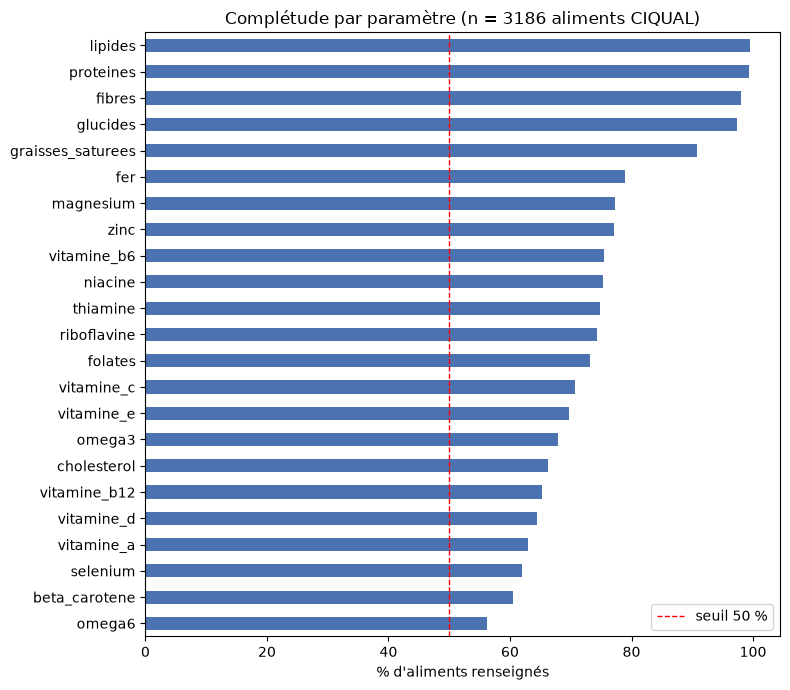

omega6               56.2
beta_carotene        60.5
selenium             62.0
vitamine_a           62.9
vitamine_d           64.4
vitamine_b12         65.2
cholesterol          66.3
omega3               67.9
vitamine_e           69.8
vitamine_c           70.7
folates              73.2
riboflavine          74.4
thiamine             74.9
niacine              75.4
vitamine_b6          75.5
zinc                 77.2
magnesium            77.3
fer                  79.0
graisses_saturees    90.8
glucides             97.4
fibres               98.1
proteines            99.4
lipides              99.5
dtype: float64


In [10]:
params = list(params_directs.keys()) + ["omega3", "omega6"]
completude = (nut[params].notna().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
completude.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("% d'aliments renseignés")
ax.set_title(f"Complétude par paramètre (n = {len(nut)} aliments CIQUAL)")
ax.axvline(50, color="red", ls="--", lw=1, label="seuil 50 %")
ax.legend()
plt.tight_layout(); plt.show()

print(completude.round(1))

**Certains aliments ont des nutriments non renseignées, on voit notamment que le beta_carotene est asymétrique. C'est une infromation très importante pour le calcul des repère pour notre échelle, une normalisation via z-score serait instable.**



La cinquième partie serait la validation et l'honnêteté : le golden set d'aliments repères connus avec leur niveau, et surtout la mise en lumière des artefacts qu'on a découverts (le romarin séché au sommet anti, le riz blanc et le yaourt qui dérivent pro, le saucisson trop anti). Montrer ces cas toi-même, avec un graphique, c'est ce qui prouvera au jury que tu comprends ton outil plutôt que de le subir.

## Mise en palce des coefficient (directement issu du Dietary Inflammatory Index) :

In [11]:
# Signe et intensité issus du Dietary Inflammatory Index (Shivappa et al., 2014).
# Énergie RETIRÉE volontairement (double comptage avec les macros + faible complétude).
# Graisses trans ABSENTES de CIQUAL.
coefs = {
    # pro-inflammatoires (+)
    "glucides": 0.097, "proteines": 0.021, "lipides": 0.298, "graisses_saturees": 0.373,
    "cholesterol": 0.110, "fer": 0.032, "vitamine_b12": 0.106,
    # anti-inflammatoires (−)
    "fibres": -0.663, "omega3": -0.436, "omega6": -0.159, "vitamine_a": -0.401,
    "beta_carotene": -0.584, "vitamine_c": -0.424, "vitamine_d": -0.446, "vitamine_e": -0.419,
    "vitamine_b6": -0.365, "folates": -0.190, "thiamine": -0.098, "riboflavine": -0.068,
    "niacine": -0.246, "magnesium": -0.484, "selenium": -0.191, "zinc": -0.313,
}
tab = pd.DataFrame({"coefficient": coefs})
tab["direction"] = np.where(tab.coefficient > 0, "pro (+)", "anti (−)")
print(f"{len(coefs)} paramètres  |  {(tab.coefficient>0).sum()} pro  /  {(tab.coefficient<0).sum()} anti")
tab.sort_values("coefficient")

23 paramètres  |  7 pro  /  16 anti


,coefficient,direction
fibres,-0.663,anti (−)
beta_carotene,-0.584,anti (−)
magnesium,-0.484,anti (−)
vitamine_d,-0.446,anti (−)
omega3,-0.436,anti (−)
vitamine_c,-0.424,anti (−)
vitamine_e,-0.419,anti (−)
vitamine_a,-0.401,anti (−)
vitamine_b6,-0.365,anti (−)
zinc,-0.313,anti (−)


La quatrième partie serait le calcul du score et la fixation des seuils sur les 3000 lignes. On calcule le score brut de tous les aliments, on trace la distribution complète, et on pose les seuils −2…+2 par quintiles. Avec 3000 aliments la distribution est enfin robuste, et tu peux montrer le graphique de répartition dans les 5 niveaux.

## Repères de normalisation figés & justification du min-max plutôt que du z-score

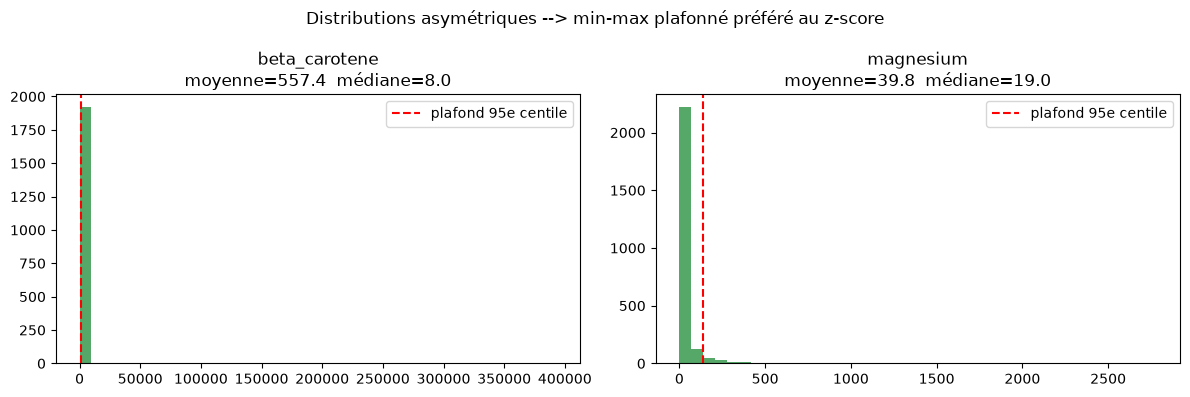

In [12]:
# Repères calculé sur les aliments pertinents uniquement : minimum et plafond au 95e centile (fige les valeurs extrêmes).
base = nut.loc[~non_pertinent]
reperes = {p: {"min": float(np.nanmin(base[p])),
               "plafond_p95": float(np.nanpercentile(base[p].dropna(), 95))} for p in coefs}

norm = pd.DataFrame(index=nut.index)
for p in coefs:
    lo, cap = reperes[p]["min"], reperes[p]["plafond_p95"]
    rng = cap - lo
    norm[p] = ((nut[p].clip(upper=cap) - lo) / rng).clip(0, 1) if rng > 0 else 0.0


# Illustration : pourquoi le z-score serait instable (distribution très asymétrique)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, p in zip(axes, ["beta_carotene", "magnesium"]):
    col = nut[p].dropna()
    ax.hist(col, bins=40, color="#55A868")
    ax.axvline(reperes[p]["plafond_p95"], color="red", ls="--", label="plafond 95e centile")
    ax.set_title(f"{p}\nmoyenne={col.mean():.1f}  médiane={col.median():.1f}")
    ax.legend()
fig.suptitle("Distributions asymétriques --> min-max plafonné préféré au z-score")
plt.tight_layout(); plt.show()

## Normalisation min max plafonne

In [13]:
norm = pd.DataFrame(index=nut.index)
for p in coefs:
    lo, cap = reperes[p]["min"], reperes[p]["plafond_p95"]
    rng = cap - lo
    if rng > 0:
        norm[p] = ((nut[p].clip(upper=cap) - lo) / rng).clip(0, 1)
    else:
        norm[p] = 0.0
norm.describe().round(2)

,glucides,proteines,lipides,graisses_saturees,cholesterol,fer,vitamine_b12,fibres,omega3,omega6,...,vitamine_d,vitamine_e,vitamine_b6,folates,thiamine,riboflavine,niacine,magnesium,selenium,zinc
count,3104.00,3167.00,3169.00,2892.00,2113.00,2516.00,2078.00,3125.00,2164.00,1789.00,...,2052.00,2223.00,2405.00,2331.00,2386.00,2370.00,2401.00,2462.00,1974.00,2459.00
mean,0.23,0.35,0.24,0.21,0.23,0.21,0.13,0.19,0.14,0.18,...,0.11,0.17,0.24,0.21,0.18,0.18,0.22,0.21,0.16,0.25
std,0.31,0.32,0.29,0.29,0.29,0.27,0.24,0.27,0.25,0.26,...,0.24,0.25,0.27,0.25,0.26,0.25,0.29,0.24,0.27,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.01,0.05,0.01,0.01,0.00,0.03,0.00,0.00,0.01,0.02,...,0.00,0.02,0.05,0.05,0.03,0.02,0.02,0.07,0.00,0.04
50%,0.08,0.24,0.11,0.07,0.08,0.10,0.03,0.09,0.05,0.08,...,0.00,0.07,0.13,0.12,0.09,0.09,0.08,0.14,0.00,0.12
75%,0.32,0.62,0.36,0.27,0.41,0.25,0.15,0.28,0.14,0.22,...,0.07,0.19,0.34,0.24,0.20,0.22,0.33,0.22,0.20,0.35
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## Calcul du score brut et gestion des données manquantes 

In [14]:
# ---------- Score + règles d'indisponibilité ----------
SEUIL_COMPLETUDE = 0.5

score = norm.mul(pd.Series(coefs)).sum(axis=1, skipna=True)
completude_alim = nut[list(params_directs.keys())].notna().mean(axis=1)

trop_de_trous = completude_alim < SEUIL_COMPLETUDE
score = score.where(~trop_de_trous, np.nan)     # données trop incomplètes
score = score.where(~non_pertinent, np.nan)     # pas d'apport nutritionnel (eau, thé nature...)
nut["score_brut"] = score

n_indispo = score.isna().sum()
print(f"Score calculé pour {score.notna().sum()} aliments | indisponible pour {n_indispo}")
print(f"  dont complétude < {SEUIL_COMPLETUDE:.0%} : {trop_de_trous.sum()}")
print(f"  dont sans apport nutritionnel  : {non_pertinent.sum()}")
print(f"  (un aliment peut cumuler les deux causes)")
print(f"\nScore brut  min={score.min():.3f}  médiane={score.median():.3f}  max={score.max():.3f}")

Score calculé pour 2342 aliments | indisponible pour 844
  dont complétude < 50% : 750
  dont sans apport nutritionnel  : 151
  (un aliment peut cumuler les deux causes)

Score brut  min=-4.122  médiane=-0.553  max=0.671


## Seuils par quintiles + distrib

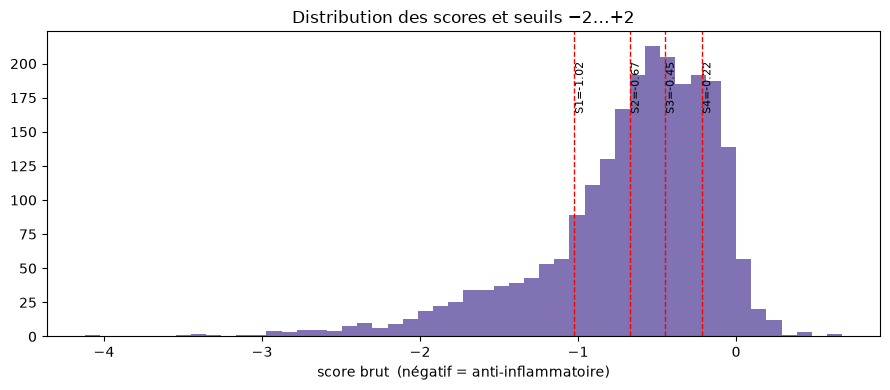


Scorés : 2342 | indisponibles : 844
Seuils : {'S1': -1.0224, 'S2': -0.6693, 'S3': -0.4478, 'S4': -0.2159}
  dont complétude < 50% : 750
  dont sans apport nutritionnel  : 151

Répartition :
niveau
-2    469
-1    468
 0    468
 1    468
 2    469


In [15]:
# ---------- Seuils recalculés ----------
q = score.quantile([0.2, 0.4, 0.6, 0.8]).values
S1, S2, S3, S4 = q
nut["niveau"] = score.map(lambda s: np.nan if pd.isna(s) else
                          (-2 if s <= S1 else -1 if s <= S2 else 0 if s <= S3 else 1 if s <= S4 else 2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(score.dropna(), bins=50, color="#8172B3")
for s, lab in zip(q, ["S1", "S2", "S3", "S4"]):
    ax.axvline(s, color="red", ls="--", lw=1)
    ax.text(s, ax.get_ylim()[1]*0.9, f"{lab}={s:.2f}", rotation=90, va="top", fontsize=8)
ax.set_xlabel("score brut  (négatif = anti-inflammatoire)")
ax.set_title("Distribution des scores et seuils −2…+2")
plt.tight_layout(); plt.show()

print(f"\nScorés : {score.notna().sum()} | indisponibles : {score.isna().sum()}")
print("Seuils :", {k: round(float(v), 4) for k, v in zip(["S1","S2","S3","S4"], q)})

# Détail des aliments non scorés : les deux causes, séparées
print(f"  dont complétude < {SEUIL_COMPLETUDE:.0%} : {(completude_alim < SEUIL_COMPLETUDE).sum()}")
print(f"  dont sans apport nutritionnel  : {non_pertinent.sum()}")

# Répartition dans les 5 niveaux
print("\nRépartition :")
print(nut["niveau"].value_counts().reindex([-2,-1,0,1,2]).to_string())

## Score par famille d'aliments

In [16]:
print("\nMédiane par famille (anti -> pro) :")
print(nut.groupby("groupe")["score_brut"].median().sort_values().round(3).to_string())

print("\nGOLDEN SET :")
for r in ["Maquereau, cru", "Saumon, cru", "Brocoli", "Lentille", "Banane, pulpe",
          "Poulet", "Oeuf, au plat", "Riz blanc", "Yaourt", "Saucisson sec",
          "Croissant", "Sucre blanc", "Beurre à 82", "Foie gras", "Huile d'olive", "Eau du robinet"]:
    h = nut[nut.nom.str.contains(r, case=False, na=False, regex=False)].head(1)
    for _, x in h.iterrows():
        niv = "indispo" if pd.isna(x.niveau) else f"{int(x.niveau):+d}"
        print(f"  [{niv:>7}]  {x.score_brut if pd.notna(x.score_brut) else float('nan'):+.3f}  {x.nom[:50]}")


Médiane par famille (anti -> pro) :
groupe
aides culinaires et ingrédients divers        -1.167
fruits, légumes, légumineuses et oléagineux   -0.730
aliments infantiles                           -0.696
viandes, œufs, poissons et assimilés          -0.625
entrées et plats composés                     -0.586
produits céréaliers                           -0.562
produits sucrés                               -0.422
produits laitiers et assimilés                -0.193
matières grasses                              -0.175
glaces et sorbets                             -0.158
eaux et autres boissons                       -0.140

GOLDEN SET :
  [     -1]  -0.757  Groseille à maquereau, crue
  [     -2]  -1.545  Saumon, cru, élevage
  [     -2]  -1.271  Brocoli, cru
  [indispo]  +nan  Salade de lentilles et saucisse fumée, préemballée
  [     +0]  -0.497  Banane, pulpe, crue
  [     -1]  -0.907  Salade César au poulet (salade verte, fromage, cro
  [     +0]  -0.524  Oeuf, au plat, frit, salé
  [i


Médiane par famille (anti -> pro) :
groupe
aides culinaires et ingrédients divers        -1.167
fruits, légumes, légumineuses et oléagineux   -0.730
aliments infantiles                           -0.696
viandes, œufs, poissons et assimilés          -0.625
entrées et plats composés                     -0.586
produits céréaliers                           -0.562
produits sucrés                               -0.422
produits laitiers et assimilés                -0.193
matières grasses                              -0.175
glaces et sorbets                             -0.158
eaux et autres boissons                       -0.140


/tmp/ipykernel_23340/2893329572.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, tick_labels=ordre)   # 'labels' -> 'tick_labels' (matplotlib 3.9+)


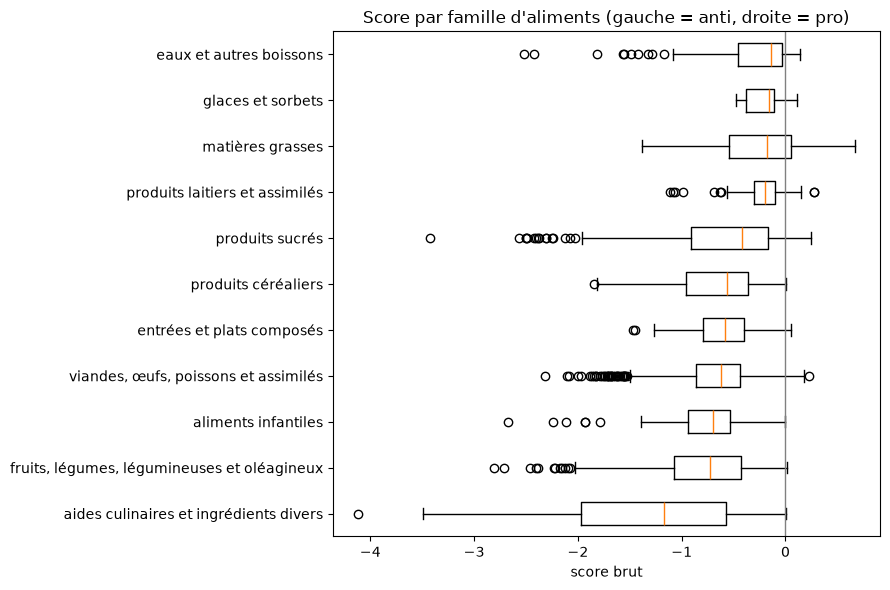

In [17]:
print("\nMédiane par famille (anti -> pro) :")
print(nut.groupby("groupe")["score_brut"].median().sort_values().round(3).to_string())

# On ne garde que les familles ayant au moins un aliment scoré
medianes = nut.groupby("groupe")["score_brut"].median().dropna().sort_values()
ordre = medianes.index

nut_box = nut.dropna(subset=["score_brut"])
data = [nut_box.loc[nut_box.groupe == g, "score_brut"].values for g in ordre]

fig, ax = plt.subplots(figsize=(9, 6))
ax.boxplot(data, vert=False, tick_labels=ordre)   # 'labels' -> 'tick_labels' (matplotlib 3.9+)
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("score brut")
ax.set_title("Score par famille d'aliments (gauche = anti, droite = pro)")
plt.tight_layout(); plt.show()

## Validation : golden set + artefacts assumés

In [18]:
print("\nGOLDEN SET :")
for r in ["Maquereau, cru", "Saumon, cru", "Brocoli", "Lentille", "Banane, pulpe",
          "Poulet", "Oeuf, au plat", "Riz blanc", "Yaourt", "Saucisson sec",
          "Croissant", "Sucre blanc", "Beurre à 82", "Foie gras", "Huile d'olive", "Eau du robinet"]:
    h = nut[nut.nom.str.contains(r, case=False, na=False, regex=False)].head(1)
    for _, x in h.iterrows():
        niv = "indispo" if pd.isna(x.niveau) else f"{int(x.niveau):+d}"
        print(f"  [{niv:>7}]  {x.score_brut if pd.notna(x.score_brut) else float('nan'):+.3f}  {x.nom[:50]}")


GOLDEN SET :
  [     -1]  -0.757  Groseille à maquereau, crue
  [     -2]  -1.545  Saumon, cru, élevage
  [     -2]  -1.271  Brocoli, cru
  [indispo]  +nan  Salade de lentilles et saucisse fumée, préemballée
  [     +0]  -0.497  Banane, pulpe, crue
  [     -1]  -0.907  Salade César au poulet (salade verte, fromage, cro
  [     +0]  -0.524  Oeuf, au plat, frit, salé
  [indispo]  +nan  Riz blanc, avec poulet, préemballé, cuit
  [indispo]  +nan  Boisson lactée, lait fermenté ou yaourt à boire, a
  [     +0]  -0.580  Saucisson sec
  [indispo]  +nan  Croissant au jambon
  [     +2]  +0.089  Sucre blanc
  [     +2]  -0.133  Beurre à 82% MG, doux
  [     +2]  -0.215  Foie gras, canard, entier, cuit
  [     -2]  -1.266  Sardine, à l'huile d'olive, appertisée, égouttée
  [indispo]  +nan  Eau du robinet


## Figer la v1.0 (à copier pour le backend)

In [19]:
print("# ===== RÉFÉRENTIEL v1.0 — à figer =====")
print("SEUILS =", {k: round(float(v),4) for k,v in zip(['S1','S2','S3','S4'], q)})
print("\nREPERES = {")
for p in coefs:
    print(f"    '{p}': {{'min': {reperes[p]['min']:.4f}, 'plafond': {reperes[p]['plafond_p95']:.4f}}},")
print("}")
print("\nCOEFS =", coefs)

# ===== RÉFÉRENTIEL v1.0 — à figer =====
SEUILS = {'S1': -1.0224, 'S2': -0.6693, 'S3': -0.4478, 'S4': -0.2159}

REPERES = {
    'glucides': {'min': 0.0000, 'plafond': 69.5000},
    'proteines': {'min': 0.0000, 'plafond': 26.2000},
    'lipides': {'min': 0.0000, 'plafond': 37.0750},
    'graisses_saturees': {'min': 0.0000, 'plafond': 18.0000},
    'cholesterol': {'min': 0.0000, 'plafond': 164.0000},
    'fer': {'min': 0.0000, 'plafond': 7.2090},
    'vitamine_b12': {'min': 0.0000, 'plafond': 7.1940},
    'fibres': {'min': 0.0000, 'plafond': 9.0000},
    'omega3': {'min': 0.0000, 'plafond': 1.2250},
    'omega6': {'min': 0.0000, 'plafond': 5.6710},
    'vitamine_a': {'min': 0.0000, 'plafond': 232.9000},
    'beta_carotene': {'min': 0.0000, 'plafond': 1253.5000},
    'vitamine_c': {'min': 0.0000, 'plafond': 41.2500},
    'vitamine_d': {'min': 0.0000, 'plafond': 3.7735},
    'vitamine_e': {'min': 0.0000, 'plafond': 7.6450},
    'vitamine_b6': {'min': 0.0000, 'plafond': 0.7300},
    'folate

## Passage à une normalisation centrée

La première version normalisait chaque nutriment entre 0 et 1 (min-max plafonné). Résultat : presque aucun aliment n'obtenait de score positif, et les corps gras ressortaient anti-inflammatoires. La cause est arithmétique : avec 16 paramètres anti-inflammatoires contre 7 pro, et des valeurs toujours positives, l'échelle s'étendait de −5,4 à +1,0 seulement. Surtout, un aliment dépourvu de fibres ou de vitamine C recevait 0, jamais de pénalité : on conservait le bonus des nutriments protecteurs sans jamais sanctionner leur absence.

On normalise donc désormais chaque nutriment entre −1 et +1 autour de sa médiane : au-dessus de la médiane, le nutriment contribue positivement ; en dessous, négativement. Le zéro redevient un point neutre réel, et l'échelle se déploie symétriquement. Cette approche se rapproche du DII original, qui centre lui aussi ses valeurs avant pondération.

## Normalisation centrée :

In [20]:
# ---------- Normalisation CENTRÉE sur la médiane : [-1, +1] ----------
# Idée : au-dessus de la médiane -> contribution positive du nutriment ;
#        en dessous -> contribution négative. Le 0 redevient un vrai neutre.
base = nut.loc[~non_pertinent]

reperes = {}
norm = pd.DataFrame(index=nut.index)
for p in coefs:
    med = float(base[p].median())
    p10 = float(base[p].quantile(0.10))
    p90 = float(base[p].quantile(0.90))
    reperes[p] = {"mediane": med, "p10": p10, "p90": p90}

    col = nut[p].astype(float)
    haut = ((col - med) / (p90 - med)).clip(0, 1) if p90 > med else 0.0   # 0 -> +1
    bas  = ((col - med) / (med - p10)).clip(-1, 0) if med > p10 else 0.0  # -1 -> 0
    norm[p] = np.where(col >= med, haut, bas)
    norm[p] = pd.Series(norm[p], index=nut.index).where(col.notna(), np.nan)

# ---------- Score ----------
SEUIL_COMPLETUDE = 0.5
score = norm.mul(pd.Series(coefs)).sum(axis=1, skipna=True)
completude_alim = nut[list(params_directs.keys())].notna().mean(axis=1)
trop_de_trous = completude_alim < SEUIL_COMPLETUDE
score = score.where(~trop_de_trous, np.nan).where(~non_pertinent, np.nan)
nut["score_brut"] = score

print(f"Scorés : {score.notna().sum()} | indisponibles : {score.isna().sum()}")
print(f"Score brut  min={score.min():.3f}  médiane={score.median():.3f}  max={score.max():.3f}")
print(f"Part de scores positifs : {(score>0).sum()} ({100*(score>0).sum()/score.notna().sum():.1f} %)")

Scorés : 2342 | indisponibles : 844
Score brut  min=-4.497  médiane=0.373  max=4.595
Part de scores positifs : 1417 (60.5 %)


## Seuils, distribution et contrôle :

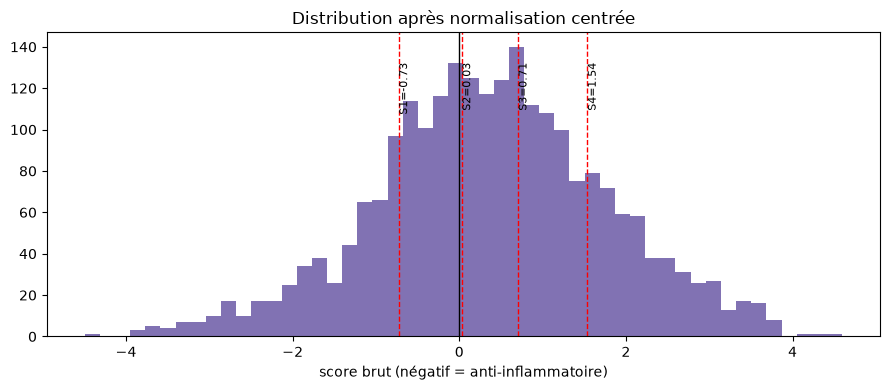

Seuils : {'S1': -0.7268, 'S2': 0.0307, 'S3': 0.7063, 'S4': 1.5368}

Médiane par famille (anti -> pro) :
groupe
aides culinaires et ingrédients divers        -0.727
aliments infantiles                           -0.311
fruits, légumes, légumineuses et oléagineux   -0.247
entrées et plats composés                     -0.238
produits céréaliers                            0.023
viandes, œufs, poissons et assimilés           0.388
produits sucrés                                0.522
glaces et sorbets                              1.216
produits laitiers et assimilés                 1.594
eaux et autres boissons                        1.973
matières grasses                               2.715

GOLDEN SET :
  [     -1] -0.519  Groseille à maquereau, crue
  [     -1] -0.413  Saumon, cru, élevage
  [     -2] -1.812  Brocoli, cru
  [indispo]   n/a    Salade de lentilles et saucisse fumée, préemballée
  [     +0] +0.203  Banane, pulpe, crue
  [     -2] -1.214  Salade César au poulet (salade verte, 

In [21]:
q = score.quantile([0.2, 0.4, 0.6, 0.8]).values
S1, S2, S3, S4 = q
nut["niveau"] = score.map(lambda s: np.nan if pd.isna(s) else
                          (-2 if s <= S1 else -1 if s <= S2 else 0 if s <= S3 else 1 if s <= S4 else 2))

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(score.dropna(), bins=50, color="#8172B3")
for s, lab in zip(q, ["S1","S2","S3","S4"]):
    ax.axvline(s, color="red", ls="--", lw=1)
    ax.text(s, ax.get_ylim()[1]*.9, f"{lab}={s:.2f}", rotation=90, va="top", fontsize=8)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("score brut (négatif = anti-inflammatoire)")
ax.set_title("Distribution après normalisation centrée")
plt.tight_layout(); plt.show()

print("Seuils :", {k: round(float(v),4) for k,v in zip(["S1","S2","S3","S4"], q)})

print("\nMédiane par famille (anti -> pro) :")
print(nut.groupby("groupe")["score_brut"].median().sort_values().round(3).to_string())

print("\nGOLDEN SET :")
for r in ["Maquereau, cru","Saumon, cru","Brocoli","Lentille","Banane, pulpe","Poulet",
          "Oeuf, au plat","Riz blanc","Yaourt","Saucisson sec","Croissant","Sucre blanc",
          "Beurre à 82","Foie gras","Huile d'olive","Huile de palme","Cola, sucré"]:
    h = nut[nut.nom.str.contains(r, case=False, na=False, regex=False)].head(1)
    for _, x in h.iterrows():
        niv = "indispo" if pd.isna(x.niveau) else f"{int(x.niveau):+d}"
        sc = "  n/a  " if pd.isna(x.score_brut) else f"{x.score_brut:+.3f}"
        print(f"  [{niv:>7}] {sc}  {x.nom[:52]}")

In [22]:
import json
print(json.dumps(reperes, ensure_ascii=False, indent=2))

{
  "glucides": {
    "mediane": 6.4,
    "p10": 0.0,
    "p90": 58.74000000000006
  },
  "proteines": {
    "mediane": 6.94,
    "p10": 0.5,
    "p90": 22.9
  },
  "lipides": {
    "mediane": 4.7,
    "p10": 0.0965,
    "p90": 27.5
  },
  "graisses_saturees": {
    "mediane": 1.475,
    "p10": 0.0135,
    "p90": 13.2
  },
  "cholesterol": {
    "mediane": 18.1,
    "p10": 0.0,
    "p90": 103.0
  },
  "fer": {
    "mediane": 0.78,
    "p10": 0.08,
    "p90": 4.5
  },
  "vitamine_b12": {
    "mediane": 0.24,
    "p10": 0.0,
    "p90": 2.82
  },
  "fibres": {
    "mediane": 1.0,
    "p10": 0.0,
    "p90": 5.2850000000000135
  },
  "omega3": {
    "mediane": 0.059,
    "p10": 0.0,
    "p90": 0.4505
  },
  "omega6": {
    "mediane": 0.45,
    "p10": 0.0038,
    "p90": 3.15
  },
  "vitamine_a": {
    "mediane": 0.0,
    "p10": 0.0,
    "p90": 150.0
  },
  "beta_carotene": {
    "mediane": 10.55,
    "p10": 0.0,
    "p90": 560.0
  },
  "vitamine_c": {
    "mediane": 0.82,
    "p10": 0.0,
   